In [ ]:
# @title **Step 1: Install and Import Dependencies**
# @markdown Run this cell to install/import required packages

import os
import sys
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
def set_seeds(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(42)

print("✅ All imports completed successfully!")
print(f"Random seed set to: 42")

✅ All imports completed successfully!
Random seed set to: 42


In [ ]:
# @title **Step 2: Check GPU Configuration**
# @markdown This cell verifies GPU setup for DeepLabV3+

import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.transforms import functional as TF
from google.colab import files

# Auto-detect device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("🚀 DEEPLABV3+ GPU CONFIGURATION")
print("=" * 60)
print(f"PyTorch Device: {DEVICE}")

if DEVICE.type == "cuda":
    print(f"🔹 GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"🔹 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"🔹 CUDA Version: {torch.version.cuda}")

    # Memory check for DeepLabV3+
    memory_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    if memory_gb < 12:
        print(f"⚠️  WARNING: {memory_gb:.1f}GB VRAM may be tight for batch size 16")
        print("   Consider reducing batch size if you encounter OOM errors")
    else:
        print(f"✅ Sufficient VRAM for DeepLabV3+ with batch size 16")
else:
    print("❌ CRITICAL ERROR: DeepLabV3+ requires GPU!")
    print("   Go to: Runtime → Change runtime type → Select GPU")
    print("   Without GPU, training will be impractically slow")
print("=" * 60)

🚀 DEEPLABV3+ GPU CONFIGURATION
PyTorch Device: cuda
🔹 GPU Name: NVIDIA A100-SXM4-40GB
🔹 GPU Memory: 42.47 GB
🔹 CUDA Version: 12.6
✅ Sufficient VRAM for DeepLabV3+ with batch size 16


In [ ]:
# @title **Step 3: Upload Dataset Files for DeepLabV3+**
# @markdown Upload your image and mask zip files
# @markdown **Instructions for DeepLabV3+:**
# @markdown 1. DeepLabV3+ benefits from larger datasets (100+ pairs recommended)
# @markdown 2. Prepare two zip files:
# @markdown    - `flowers.zip`: Contains RGB images (.jpg/.png)
# @markdown    - `masks_semantic.zip`: Contains binary masks (.png)
# @markdown 3. Ensure matching filenames (e.g., flower1.jpg ↔ flower1.png)
# @markdown 4. Images will be resized to 256x256

from google.colab import files
import zipfile
import time

# Define folder paths
IMG_DEST = "/content/dataset"
MASK_DEST = "/content/masks"

# Clean previous runs
for d in [IMG_DEST, MASK_DEST]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

print("📁 Folder structure created for DeepLabV3+ training:")
print(f"   Images will be saved to: {IMG_DEST}")
print(f"   Masks will be saved to: {MASK_DEST}")
print()

# Upload images
print("⬇️" * 30)
print("STEP 1: Upload ORIGINAL IMAGES Zip file (e.g., flowers.zip)")
print("⬇️" * 30)
uploaded_img = files.upload()
img_zip = list(uploaded_img.keys())[0]
print(f"✅ Uploaded: {img_zip} ({os.path.getsize(img_zip)/1024/1024:.2f} MB)")

# Upload masks
print("\n" + "⬇️" * 30)
print("STEP 2: Upload MASKS Zip file (e.g., masks_semantic.zip)")
print("⬇️" * 30)
uploaded_mask = files.upload()
mask_zip = list(uploaded_mask.keys())[0]
print(f"✅ Uploaded: {mask_zip} ({os.path.getsize(mask_zip)/1024/1024:.2f} MB)")

print("\n⏳ Extracting files...")
start_time = time.time()

# Extract images
with zipfile.ZipFile(img_zip, 'r') as zip_ref:
    zip_ref.extractall(IMG_DEST)

# Extract masks
with zipfile.ZipFile(mask_zip, 'r') as zip_ref:
    zip_ref.extractall(MASK_DEST)

extract_time = time.time() - start_time
print(f"✅ Extraction complete in {extract_time:.1f} seconds!")
print(f"📊 Image folder: {len(os.listdir(IMG_DEST))} items")
print(f"📊 Mask folder: {len(os.listdir(MASK_DEST))} items")

📁 Folder structure created for DeepLabV3+ training:
   Images will be saved to: /content/dataset
   Masks will be saved to: /content/masks

⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️
STEP 1: Upload ORIGINAL IMAGES Zip file (e.g., flowers.zip)
⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️


Saving archive (5).zip to archive (5).zip
✅ Uploaded: archive (5).zip (184.38 MB)

⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️
STEP 2: Upload MASKS Zip file (e.g., masks_semantic.zip)
⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️


Saving final_bw_masks.zip to final_bw_masks.zip
✅ Uploaded: final_bw_masks.zip (7.50 MB)

⏳ Extracting files...
✅ Extraction complete in 2.3 seconds!
📊 Image folder: 8 items
📊 Mask folder: 7397 items


🔍 Found 7397 image files


Matching files:   0%|          | 0/7397 [00:00<?, ?it/s]


📊 DEEPLABV3+ DATA SUMMARY
✅ Successfully matched: 7397 pairs
⚠️  Unmatched images: 0

✅ Good dataset size for DeepLabV3+: 7397 pairs

🔍 Sample matched pair for DeepLabV3+:
   Image: Costus Speciosus Augmented 10.jpg
   Mask: Costus Speciosus Augmented 10.png


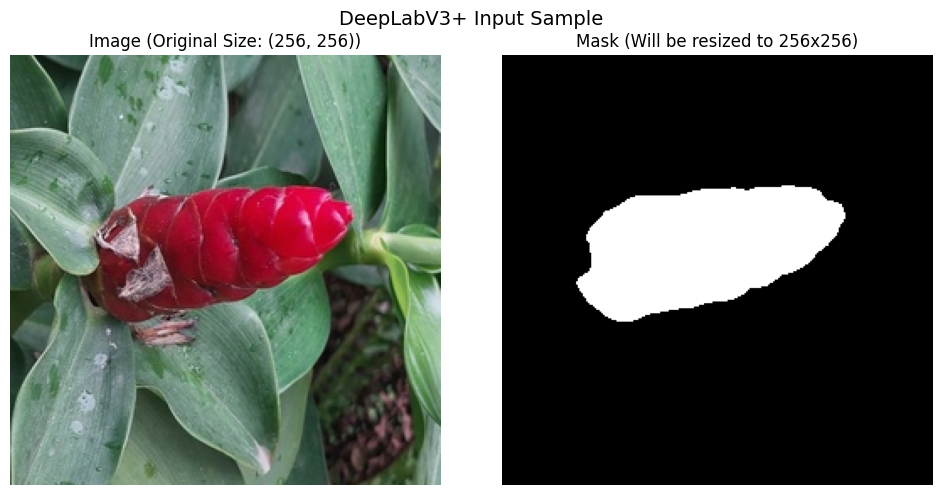

In [ ]:
# @title **Step 4: Data Inspection & Pair Matching**
# @markdown This cell checks your data and creates image-mask pairs for DeepLabV3+
from PIL import Image

def match_pairs(img_folder, mask_folder):
    """Match image files with corresponding mask files"""
    valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

    # Get all image files
    img_paths = []
    for ext in valid_exts:
        img_paths.extend(list(Path(img_folder).rglob(f"*{ext}")))
        img_paths.extend(list(Path(img_folder).rglob(f"*{ext.upper()}")))

    img_paths = sorted(img_paths)
    print(f"🔍 Found {len(img_paths)} image files")

    # Match with masks
    pairs = []
    unmatched = []

    for img_p in tqdm(img_paths, desc="Matching files"):
        stem = img_p.stem
        # Try to find matching mask
        mask_found = False
        for ext in valid_exts:
            mask_path = Path(mask_folder) / f"{stem}{ext}"
            if mask_path.exists():
                pairs.append((str(img_p), str(mask_path)))
                mask_found = True
                break
            # Also check uppercase extension
            mask_path = Path(mask_folder) / f"{stem}{ext.upper()}"
            if mask_path.exists():
                pairs.append((str(img_p), str(mask_path)))
                mask_found = True
                break

        if not mask_found:
            unmatched.append(str(img_p))

    return pairs, unmatched

# Match pairs
pairs, unmatched = match_pairs(IMG_DEST, MASK_DEST)

print("\n" + "=" * 60)
print("📊 DEEPLABV3+ DATA SUMMARY")
print("=" * 60)
print(f"✅ Successfully matched: {len(pairs)} pairs")
print(f"⚠️  Unmatched images: {len(unmatched)}")

# DeepLabV3+ dataset size recommendations
if len(pairs) < 50:
    print(f"\n⚠️  WARNING: Only {len(pairs)} pairs found")
    print("   DeepLabV3+ performs best with 100+ image-mask pairs")
    print("   Consider collecting more data or using data augmentation")
elif len(pairs) >= 100:
    print(f"\n✅ Good dataset size for DeepLabV3+: {len(pairs)} pairs")

if len(unmatched) > 0:
    print("\n❌ Unmatched files (check filenames):")
    for f in unmatched[:5]:  # Show first 5
        print(f"   - {Path(f).name}")
    if len(unmatched) > 5:
        print(f"   ... and {len(unmatched)-5} more")

if len(pairs) == 0:
    raise ValueError("❌ CRITICAL ERROR: No image-mask pairs found!")
    print("💡 Check that:")
    print("   1. Filenames match (e.g., 'image1.jpg' ↔ 'image1.png')")
    print("   2. Files are in correct folders")
    print("   3. File extensions are supported (.jpg, .png, etc.)")

# Display sample pair
if len(pairs) > 0:
    print("\n🔍 Sample matched pair for DeepLabV3+:")
    img_path, mask_path = pairs[0]
    print(f"   Image: {Path(img_path).name}")
    print(f"   Mask: {Path(mask_path).name}")

    # Show sample image and mask
    try:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        axes[0].imshow(img)
        axes[0].set_title(f"Image (Original Size: {img.size})")
        axes[0].axis('off')

        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title(f"Mask (Will be resized to 256x256)")
        axes[1].axis('off')

        plt.suptitle("DeepLabV3+ Input Sample", fontsize=14)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️ Could not display sample: {e}")

In [ ]:
# @title **Step 5: Create Train/Validation Splits for DeepLabV3+**
# @markdown This cell splits data into training (80%) and validation (20%) sets

# Shuffle pairs with fixed seed for reproducibility
random.shuffle(pairs)

# Split ratio
TRAIN_RATIO = 0.8
split_idx = int(len(pairs) * TRAIN_RATIO)

train_pairs = pairs[:split_idx]
val_pairs = pairs[split_idx:]

print("📊 DEEPLABV3+ DATA SPLIT SUMMARY")
print("=" * 60)
print(f"Total pairs: {len(pairs)}")
print(f"Training set: {len(train_pairs)} pairs ({len(train_pairs)/len(pairs)*100:.1f}%)")
print(f"Validation set: {len(val_pairs)} pairs ({len(val_pairs)/len(pairs)*100:.1f}%)")

# DeepLabV3+ specific recommendations
if len(train_pairs) < 40:
    print("\n⚠️  WARNING: Training set very small (<40 images)!")
    print("   DeepLabV3+ may overfit with insufficient data.")
    print("   Consider: ")
    print("   1. Collecting more data")
    print("   2. Using heavy data augmentation")
    print("   3. Reducing model complexity")

if len(val_pairs) < 10:
    print("\n⚠️  WARNING: Validation set very small (<10 images)!")
    print("   Validation metrics may not be reliable for DeepLabV3+.")

# Display split statistics
print("\n📈 Recommended for DeepLabV3+:")
print("   - Minimum training samples: 100+")
print("   - Minimum validation samples: 20+")
print("   - Current status: ", end="")
if len(train_pairs) >= 100 and len(val_pairs) >= 20:
    print("✅ Good")
else:
    print("⚠️  Below optimal")

📊 DEEPLABV3+ DATA SPLIT SUMMARY
Total pairs: 7397
Training set: 5917 pairs (80.0%)
Validation set: 1480 pairs (20.0%)

📈 Recommended for DeepLabV3+:
   - Minimum training samples: 100+
   - Minimum validation samples: 20+
   - Current status: ✅ Good


✅ DeepLabV3+ Datasets created successfully!
Training samples: 5917
Validation samples: 1480

🔍 Visualizing a training sample for DeepLabV3+:


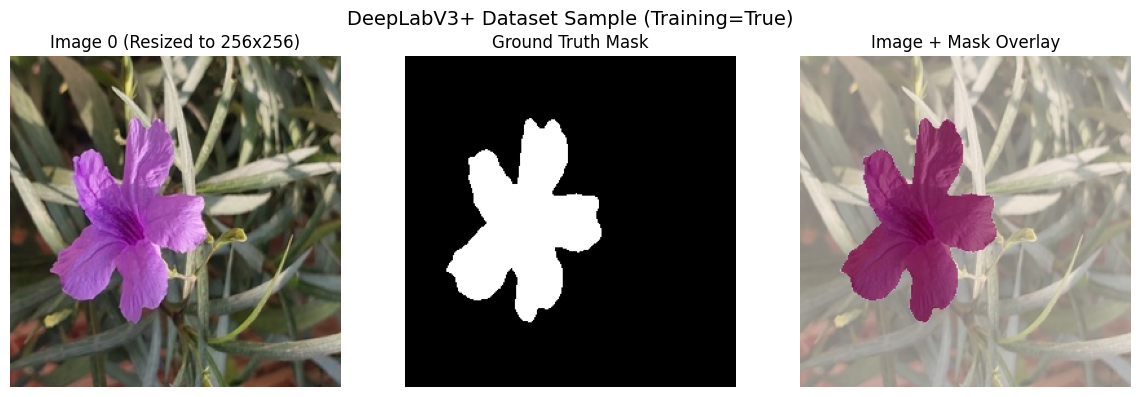

In [ ]:
# @title **Step 6: Define Dataset Class for DeepLabV3+**
# @markdown This cell defines the PyTorch Dataset class optimized for DeepLabV3+

class DeepLabDataset(Dataset):
    """PyTorch Dataset for DeepLabV3+ segmentation"""

    def __init__(self, pairs, image_size=256, train=True):
        """
        Args:
            pairs: List of (image_path, mask_path) tuples
            image_size: Size to resize images to (square)
            train: If True, apply data augmentation
        """
        self.pairs = pairs
        self.image_size = image_size
        self.train = train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        # Get paths
        img_path, mask_path = self.pairs[idx]

        # Load image and mask
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Resize (DeepLabV3+ typically uses 256x256 or 512x512)
        img = img.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)

        # Data augmentation (only during training)
        if self.train and random.random() > 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)

        # Convert to tensors
        img_tensor = TF.to_tensor(img)  # Shape: [3, H, W]
        mask_tensor = TF.to_tensor(mask)  # Shape: [1, H, W]

        # Convert mask to binary (0 or 1)
        mask_tensor = (mask_tensor > 0.5).float()

        return img_tensor, mask_tensor

    def visualize_sample(self, idx=0):
        """Visualize a sample from the dataset"""
        img, mask = self.__getitem__(idx)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        # Show original image
        axes[0].imshow(img.permute(1, 2, 0))
        axes[0].set_title(f"Image {idx} (Resized to {self.image_size}x{self.image_size})")
        axes[0].axis('off')

        # Show mask
        axes[1].imshow(mask.squeeze(), cmap='gray')
        axes[1].set_title("Ground Truth Mask")
        axes[1].axis('off')

        # Show overlay
        axes[2].imshow(img.permute(1, 2, 0))
        axes[2].imshow(mask.squeeze(), cmap='Reds', alpha=0.5)
        axes[2].set_title("Image + Mask Overlay")
        axes[2].axis('off')

        plt.suptitle(f"DeepLabV3+ Dataset Sample (Training={self.train})", fontsize=14)
        plt.tight_layout()
        plt.show()

# Create dataset instances
train_dataset = DeepLabDataset(train_pairs, image_size=256, train=True)
val_dataset = DeepLabDataset(val_pairs, image_size=256, train=False)

print("✅ DeepLabV3+ Datasets created successfully!")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Visualize a sample
print("\n🔍 Visualizing a training sample for DeepLabV3+:")
train_dataset.visualize_sample(0)

In [ ]:
# @title **Step 7: Define Evaluation Metrics for DeepLabV3+**
# @markdown This cell defines metrics for DeepLabV3+ evaluation

def calculate_metrics(pred, target, threshold=0.5):
    """
    Calculate Dice coefficient and IoU for binary segmentation

    Args:
        pred: Model predictions (logits) shape: [B, 1, H, W]
        target: Ground truth masks shape: [B, 1, H, W]
        threshold: Threshold for binary conversion

    Returns:
        dice: Dice coefficient (F1 score)
        iou: Intersection over Union
    """
    # Convert logits to probabilities and then to binary
    pred_prob = torch.sigmoid(pred)
    pred_binary = (pred_prob > threshold).float()

    # Flatten tensors
    pred_flat = pred_binary.view(-1)
    target_flat = target.view(-1).float()

    # Calculate intersection and union
    intersection = (pred_flat * target_flat).sum()
    union = pred_flat.sum() + target_flat.sum()

    # Dice coefficient (F1 score)
    dice = (2. * intersection) / (union + 1e-6)

    # IoU (Jaccard Index)
    iou = intersection / (union - intersection + 1e-6)

    return dice.item(), iou.item()

print("✅ DeepLabV3+ Metrics function defined")
print("   - Dice Coefficient (F1 Score)")
print("   - Intersection over Union (IoU)")
print("\n📊 Metrics will be calculated on both:")
print("   - Main output")
print("   - Auxiliary output (weighted 0.4 in loss)")

✅ DeepLabV3+ Metrics function defined
   - Dice Coefficient (F1 Score)
   - Intersection over Union (IoU)

📊 Metrics will be calculated on both:
   - Main output
   - Auxiliary output (weighted 0.4 in loss)


In [ ]:
# @title **Step 8: Initialize DeepLabV3+ Model**
# @markdown This cell initializes DeepLabV3+ with ResNet50 backbone

import torch.nn as nn
from torchvision.models.segmentation import deeplabv3_resnet50

print("🧪 Initializing DeepLabV3+ with ResNet50 backbone...")
print("=" * 60)

# Load pre-trained DeepLabV3+
model = deeplabv3_resnet50(weights='DEFAULT')

# Modify the classifier for binary segmentation (1 class)
# Original output channels: 21 (for Pascal VOC)
# Change to 1 for binary segmentation
model.classifier[4] = nn.Conv2d(256, 1, kernel_size=(1, 1))
model.aux_classifier[4] = nn.Conv2d(256, 1, kernel_size=(1, 1))

# Move model to device
model = model.to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("✅ DeepLabV3+ Model created successfully!")
print("=" * 60)
print("📊 DEEPLABV3+ ARCHITECTURE SUMMARY")
print("=" * 60)
print(f"Backbone: ResNet50 (pre-trained on ImageNet)")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: {total_params * 4 / (1024**2):.2f} MB (float32)")
print(f"Device: {next(model.parameters()).device}")
print(f"Output channels: 1 (binary segmentation)")
print("=" * 60)

# Memory estimation for training
if DEVICE.type == "cuda":
    memory_info = torch.cuda.memory_allocated() / 1e9
    print(f"\n📈 Memory usage after model loading: {memory_info:.2f} GB")

    # Estimate training memory
    batch_size = 16
    estimated_training_memory = memory_info + (batch_size * 256 * 256 * 4 * 5 / 1e9)  # Rough estimate
    print(f"Estimated training memory (batch={batch_size}): {estimated_training_memory:.2f} GB")

    available_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    if estimated_training_memory > available_memory * 0.9:
        print("⚠️  WARNING: Estimated memory usage exceeds 90% of available VRAM")
        print("   Consider reducing batch size if you encounter OOM errors")
    else:
        print(f"✅ Estimated memory usage: {estimated_training_memory/available_memory*100:.1f}% of available VRAM")

# Test forward pass
if len(train_pairs) > 0:
    print("\n🔍 Testing forward pass...")
    test_batch = torch.randn(2, 3, 256, 256).to(DEVICE)
    with torch.no_grad():
        output = model(test_batch)
    print(f"   Input shape: {test_batch.shape}")
    print(f"   Output keys: {output.keys()}")
    print(f"   Main output shape: {output['out'].shape}")
    print(f"   Aux output shape: {output['aux'].shape}")
    print("✅ DeepLabV3+ forward pass working correctly!")

🧪 Initializing DeepLabV3+ with ResNet50 backbone...
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 242MB/s]


✅ DeepLabV3+ Model created successfully!
📊 DEEPLABV3+ ARCHITECTURE SUMMARY
Backbone: ResNet50 (pre-trained on ImageNet)
Total parameters: 41,993,794
Trainable parameters: 41,993,794
Model size: 160.19 MB (float32)
Device: cuda:0
Output channels: 1 (binary segmentation)

📈 Memory usage after model loading: 0.17 GB
Estimated training memory (batch=16): 0.19 GB
✅ Estimated memory usage: 0.5% of available VRAM

🔍 Testing forward pass...
   Input shape: torch.Size([2, 3, 256, 256])
   Output keys: odict_keys(['out', 'aux'])
   Main output shape: torch.Size([2, 1, 256, 256])
   Aux output shape: torch.Size([2, 1, 256, 256])
✅ DeepLabV3+ forward pass working correctly!


In [ ]:
# @title **Step 9: Configure DeepLabV3+ Training Parameters**
# @markdown Adjust training hyperparameters for DeepLabV3+

# Hyperparameters
BATCH_SIZE = 16          # @param {type:"integer"}
LEARNING_RATE = 1e-4     # @param {type:"number"}
EPOCHS = 50             # @param {type:"integer"}
IMAGE_SIZE = 256         # @param {type:"integer"}
AUX_WEIGHT = 0.4         # @param {type:"number"}

print("🎯 DEEPLABV3+ TRAINING CONFIGURATION")
print("=" * 60)
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Epochs: {EPOCHS}")
print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Auxiliary loss weight: {AUX_WEIGHT}")
print(f"Training samples: {len(train_pairs)}")
print(f"Validation samples: {len(val_pairs)}")
print(f"Device: {DEVICE}")
print("=" * 60)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True if DEVICE.type == "cuda" else False,
    drop_last=True  # Drop last incomplete batch
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if DEVICE.type == "cuda" else False
)

print(f"\n✅ DeepLabV3+ Data loaders created:")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")

# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()  # Binary Cross Entropy with logits
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"\n✅ Loss function: {criterion.__class__.__name__}")
print(f"✅ Optimizer: Adam (lr={LEARNING_RATE})")
print(f"✅ Total loss = Main loss + {AUX_WEIGHT} * Auxiliary loss")

# Memory check before training
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    print(f"\n🧹 Cleared GPU cache")
    print(f"   Free memory: {torch.cuda.memory_reserved(0)/1e9:.2f} GB reserved")

🎯 DEEPLABV3+ TRAINING CONFIGURATION
Batch size: 16
Learning rate: 0.0001
Epochs: 50
Image size: 256x256
Auxiliary loss weight: 0.4
Training samples: 5917
Validation samples: 1480
Device: cuda

✅ DeepLabV3+ Data loaders created:
   Training batches: 369
   Validation batches: 93

✅ Loss function: BCEWithLogitsLoss
✅ Optimizer: Adam (lr=0.0001)
✅ Total loss = Main loss + 0.4 * Auxiliary loss

🧹 Cleared GPU cache
   Free memory: 1.26 GB reserved


In [ ]:
# @title **Step 10: Start DeepLabV3+ Training**
# @markdown **Run this cell to begin DeepLabV3+ training** (30-50 minutes on GPU)

import time
from datetime import datetime

# Training history storage
history = {
    'train_loss': [], 'val_loss': [],
    'train_dice': [], 'val_dice': [],
    'train_iou': [], 'val_iou': [],
    'best_epoch': 0
}

print("🚀 STARTING DEEPLABV3+ TRAINING")
print("=" * 60)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Epochs: {EPOCHS}")
print(f"Backbone: ResNet50 (pre-trained)")
print("=" * 60)

# Track best model
best_val_iou = 0.0
best_model_state = None
best_epoch = 0

# Start timing
start_time = time.time()

# Training loop
for epoch in range(EPOCHS):
    epoch_start_time = time.time()

    # ===== TRAINING PHASE =====
    model.train()
    train_loss = 0.0
    train_dice = 0.0
    train_iou = 0.0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:03d}/{EPOCHS} [Train]",
                     leave=False, bar_format='{l_bar}{bar:20}{r_bar}{bar:-20b}')

    for images, masks in train_pbar:
        # Move to device
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)  # Returns dict with 'out' and 'aux'

        # Calculate combined loss (main + auxiliary)
        main_loss = criterion(outputs['out'], masks)
        aux_loss = criterion(outputs['aux'], masks)
        loss = main_loss + AUX_WEIGHT * aux_loss

        # Backward pass
        loss.backward()
        optimizer.step()

        # Calculate metrics on main output
        dice, iou = calculate_metrics(outputs['out'], masks)

        # Accumulate
        train_loss += loss.item()
        train_dice += dice
        train_iou += iou

        # Update progress bar
        train_pbar.set_postfix({
            'Loss': f"{loss.item():.4f}",
            'Dice': f"{dice:.4f}",
            'IoU': f"{iou:.4f}"
        })

    # Average training metrics
    train_loss /= len(train_loader)
    train_dice /= len(train_loader)
    train_iou /= len(train_loader)

    history['train_loss'].append(train_loss)
    history['train_dice'].append(train_dice)
    history['train_iou'].append(train_iou)

    # ===== VALIDATION PHASE =====
    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1:03d}/{EPOCHS} [Val]",
                   leave=False, bar_format='{l_bar}{bar:20}{r_bar}{bar:-20b}')

    with torch.no_grad():
        for images, masks in val_pbar:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)

            # Validation loss (only on main output)
            loss = criterion(outputs['out'], masks)

            dice, iou = calculate_metrics(outputs['out'], masks)

            val_loss += loss.item()
            val_dice += dice
            val_iou += iou

            val_pbar.set_postfix({
                'Loss': f"{loss.item():.4f}",
                'Dice': f"{dice:.4f}",
                'IoU': f"{iou:.4f}"
            })

    # Average validation metrics
    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou /= len(val_loader)

    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)

    # Save best model based on validation IoU
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        best_model_state = model.state_dict().copy()
        best_epoch = epoch + 1
        history['best_epoch'] = best_epoch

        # Save best model checkpoint
        torch.save({
            'epoch': best_epoch,
            'model_state_dict': best_model_state,
            'optimizer_state_dict': optimizer.state_dict(),
            'val_iou': best_val_iou,
            'val_dice': val_dice,
        }, "DeepLabV3_Best.pth")

    # Calculate epoch time
    epoch_time = time.time() - epoch_start_time
    remaining_time = epoch_time * (EPOCHS - epoch - 1)

    # Print epoch summary
    print(f"Epoch {epoch+1:03d}/{EPOCHS} | "
          f"Time: {epoch_time:.1f}s | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Val Dice: {val_dice:.4f} | Val IoU: {val_iou:.4f} | "
          f"Best IoU: {best_val_iou:.4f} (Epoch {best_epoch})")

# Training completion
total_time = time.time() - start_time
hours, remainder = divmod(total_time, 3600)
minutes, seconds = divmod(remainder, 60)

print("\n" + "=" * 60)
print("✅ DEEPLABV3+ TRAINING COMPLETED SUCCESSFULLY!")
print("=" * 60)
print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total training time: {int(hours)}h {int(minutes)}m {int(seconds)}s")
print(f"Best validation IoU: {best_val_iou:.4f} (Epoch {best_epoch})")
print(f"Best validation Dice: {max(history['val_dice']):.4f}")
print("=" * 60)

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"✅ Loaded best DeepLabV3+ model from epoch {best_epoch}")

🚀 STARTING DEEPLABV3+ TRAINING
Start time: 2025-12-18 18:51:56
Epochs: 50
Backbone: ResNet50 (pre-trained)


Epoch 001/50 [Train]:   0%|                    | 0/369 [00:00<?, ?it/s]

Epoch 001/50 [Val]:   0%|                    | 0/93 [00:00<?, ?it/s]

Epoch 001/50 | Time: 37.3s | Train Loss: 0.0249 | Val Loss: 0.6453 | Val Dice: 0.7642 | Val IoU: 0.6304 | Best IoU: 0.6304 (Epoch 1)


Epoch 002/50 [Train]:   0%|                    | 0/369 [00:00<?, ?it/s]

...

Epoch 049/50 [Val]:   0%|                    | 0/93 [00:00<?, ?it/s]

Epoch 049/50 | Time: 36.3s | Train Loss: 0.0196 | Val Loss: 0.6700 | Val Dice: 0.7571 | Val IoU: 0.6220 | Best IoU: 0.6450 (Epoch 27)


Epoch 050/50 [Train]:   0%|                    | 0/369 [00:00<?, ?it/s]

Epoch 050/50 [Val]:   0%|                    | 0/93 [00:00<?, ?it/s]

Epoch 050/50 | Time: 36.3s | Train Loss: 0.0201 | Val Loss: 0.6972 | Val Dice: 0.7656 | Val IoU: 0.6321 | Best IoU: 0.6450 (Epoch 27)

✅ DEEPLABV3+ TRAINING COMPLETED SUCCESSFULLY!
End time: 2025-12-18 19:27:07
Total training time: 0h 35m 11s
Best validation IoU: 0.6450 (Epoch 27)
Best validation Dice: 0.7751
✅ Loaded best DeepLabV3+ model from epoch 27


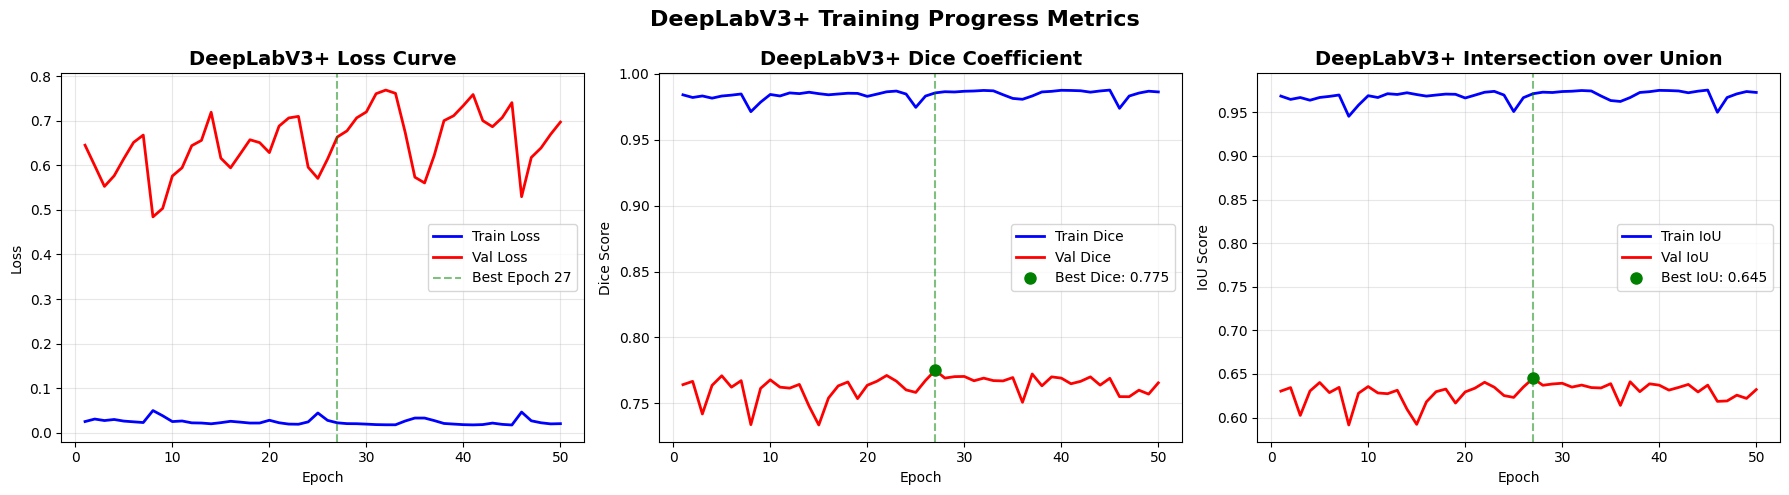


📊 DEEPLABV3+ FINAL MODEL PERFORMANCE
Best Validation IoU: 0.6450 (Epoch 27)
Best Validation Dice: 0.7751
Final Validation IoU: 0.6321
Final Validation Dice: 0.7656
Training Samples: 5917
Validation Samples: 1480


In [ ]:
# @title **Step 11: Plot DeepLabV3+ Training Curves**
# @markdown Visualize DeepLabV3+ training and validation metrics

def plot_deeplab_training_curves(history):
    """Plot training history curves for DeepLabV3+"""
    epochs = range(1, len(history['train_loss']) + 1)
    best_epoch = history.get('best_epoch', 0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    if best_epoch > 0:
        axes[0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5, label=f'Best Epoch {best_epoch}')
    axes[0].set_title('DeepLabV3+ Loss Curve', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot Dice
    axes[1].plot(epochs, history['train_dice'], 'b-', label='Train Dice', linewidth=2)
    axes[1].plot(epochs, history['val_dice'], 'r-', label='Val Dice', linewidth=2)
    if best_epoch > 0:
        axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5)
        axes[1].plot(best_epoch, max(history['val_dice']), 'go', markersize=8, label=f'Best Dice: {max(history["val_dice"]):.3f}')
    axes[1].set_title('DeepLabV3+ Dice Coefficient', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Dice Score')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Plot IoU
    axes[2].plot(epochs, history['train_iou'], 'b-', label='Train IoU', linewidth=2)
    axes[2].plot(epochs, history['val_iou'], 'r-', label='Val IoU', linewidth=2)
    if best_epoch > 0:
        axes[2].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5)
        axes[2].plot(best_epoch, max(history['val_iou']), 'go', markersize=8, label=f'Best IoU: {max(history["val_iou"]):.3f}')
    axes[2].set_title('DeepLabV3+ Intersection over Union', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('IoU Score')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle('DeepLabV3+ Training Progress Metrics', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print final metrics
    print("\n📊 DEEPLABV3+ FINAL MODEL PERFORMANCE")
    print("=" * 50)
    print(f"Best Validation IoU: {max(history['val_iou']):.4f} (Epoch {best_epoch})")
    print(f"Best Validation Dice: {max(history['val_dice']):.4f}")
    print(f"Final Validation IoU: {history['val_iou'][-1]:.4f}")
    print(f"Final Validation Dice: {history['val_dice'][-1]:.4f}")
    print(f"Training Samples: {len(train_pairs)}")
    print(f"Validation Samples: {len(val_pairs)}")
    print("=" * 50)

# Plot curves
plot_deeplab_training_curves(history)

🎨 VISUALIZING DEEPLABV3+ PREDICTIONS


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ba59f30e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1618, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
    

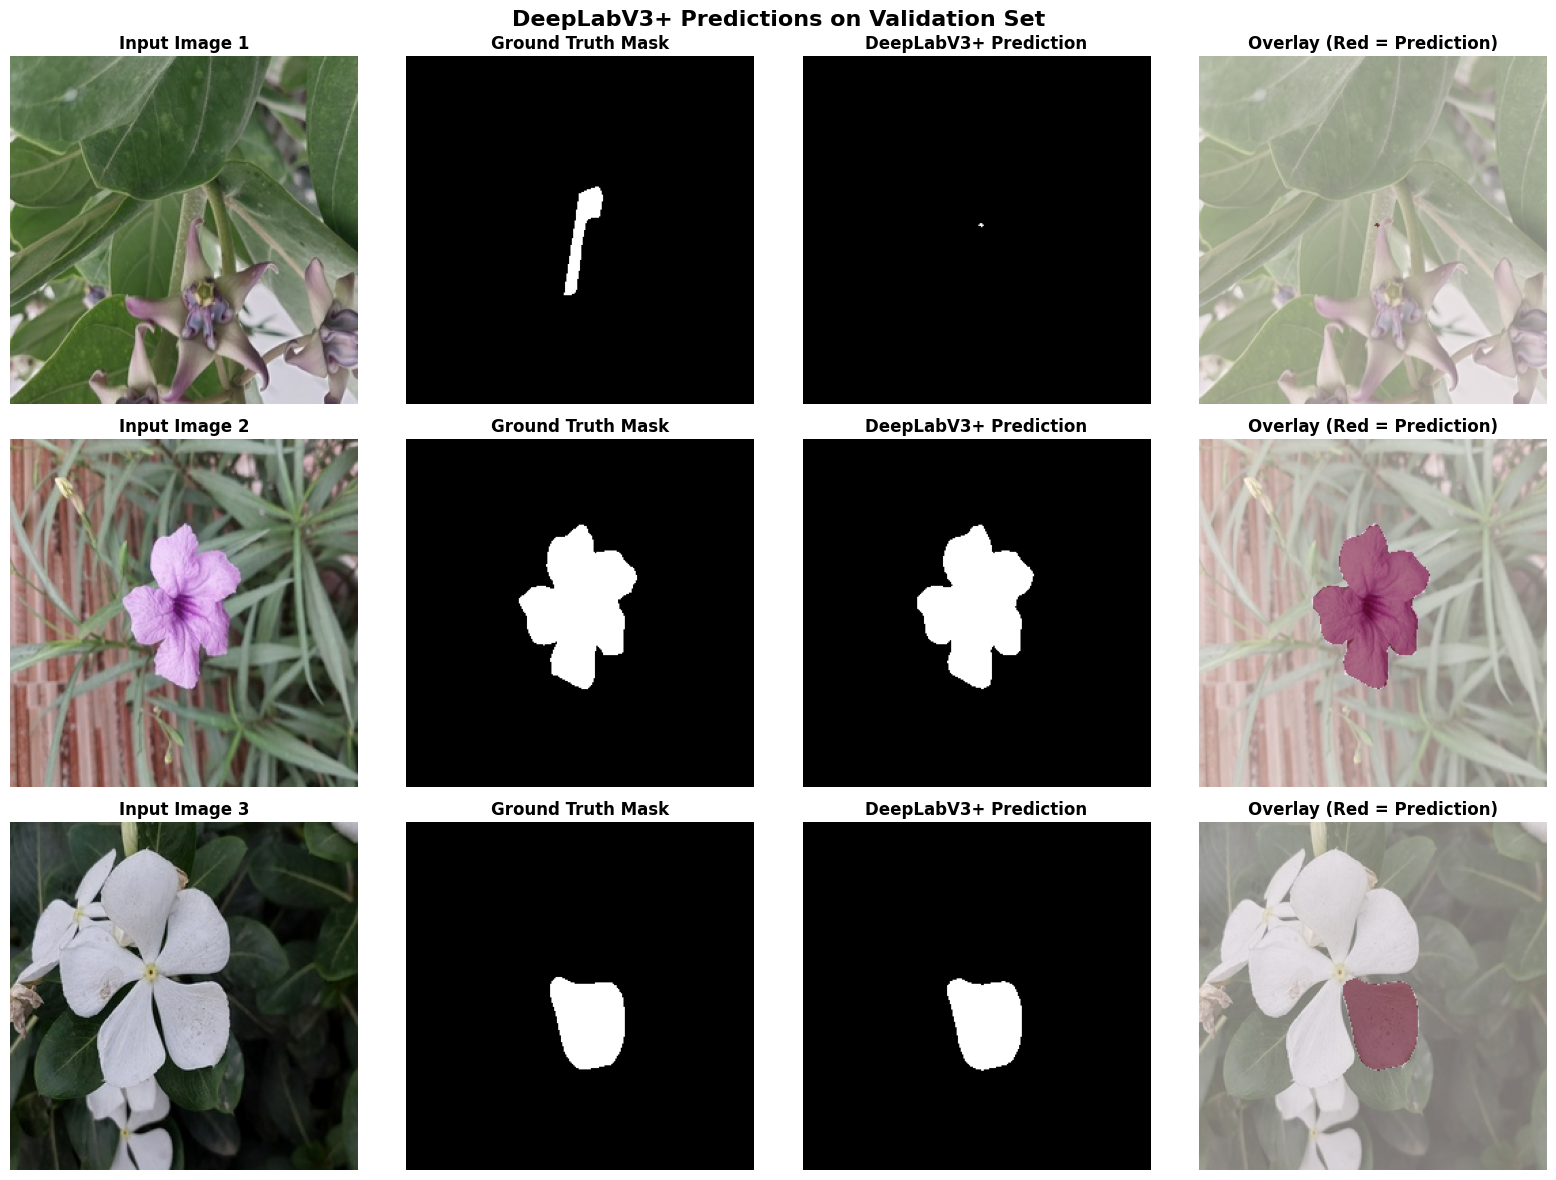


📈 Metrics for displayed samples:
Sample 1: Dice = 0.0140, IoU = 0.0071
Sample 2: Dice = 0.9890, IoU = 0.9783
Sample 3: Dice = 0.9909, IoU = 0.9820


In [ ]:
# @title **Step 12: Visualize DeepLabV3+ Predictions - COMPLETE**
# @markdown Show DeepLabV3+ predictions on validation samples

def visualize_deeplab_predictions(model, dataloader, num_samples=3):
    """Visualize DeepLabV3+ predictions on sample images"""
    model.eval()

    # Get a batch of validation data
    images, masks = next(iter(dataloader))
    images = images.to(DEVICE)

    # Get predictions
    with torch.no_grad():
        outputs = model(images)
        # DeepLabV3+ returns a dictionary with 'out' and 'aux' keys
        if isinstance(outputs, dict):
            preds_logits = outputs['out']
        else:
            preds_logits = outputs

        preds_probs = torch.sigmoid(preds_logits)
        preds_binary = (preds_probs > 0.5).float()

    # Move to CPU for visualization
    images = images.cpu()
    masks = masks.cpu()
    preds_binary = preds_binary.cpu()

    # Plot results
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_samples):
        if i >= len(images):
            break

        # Original Image
        axes[i, 0].imshow(images[i].permute(1, 2, 0))
        axes[i, 0].set_title(f"Input Image {i+1}", fontweight='bold')
        axes[i, 0].axis('off')

        # Ground Truth Mask
        axes[i, 1].imshow(masks[i].squeeze(), cmap='gray')
        axes[i, 1].set_title("Ground Truth Mask", fontweight='bold')
        axes[i, 1].axis('off')

        # Predicted Mask
        axes[i, 2].imshow(preds_binary[i].squeeze(), cmap='gray')
        axes[i, 2].set_title("DeepLabV3+ Prediction", fontweight='bold')
        axes[i, 2].axis('off')

        # Overlay
        axes[i, 3].imshow(images[i].permute(1, 2, 0))
        axes[i, 3].imshow(preds_binary[i].squeeze(), cmap='Reds', alpha=0.5)
        axes[i, 3].set_title("Overlay (Red = Prediction)", fontweight='bold')
        axes[i, 3].axis('off')

    plt.suptitle('DeepLabV3+ Predictions on Validation Set', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Calculate metrics for displayed samples
    print("\n📈 Metrics for displayed samples:")
    for i in range(min(num_samples, len(images))):
        dice, iou = calculate_metrics(preds_logits[i:i+1], masks[i:i+1].to(DEVICE))
        print(f"Sample {i+1}: Dice = {dice:.4f}, IoU = {iou:.4f}")

# Visualize predictions
print("🎨 VISUALIZING DEEPLABV3+ PREDICTIONS")
print("=" * 60)
visualize_deeplab_predictions(model, val_loader, num_samples=3)

🎨 ENHANCED DEEPLABV3+ VISUALIZATION


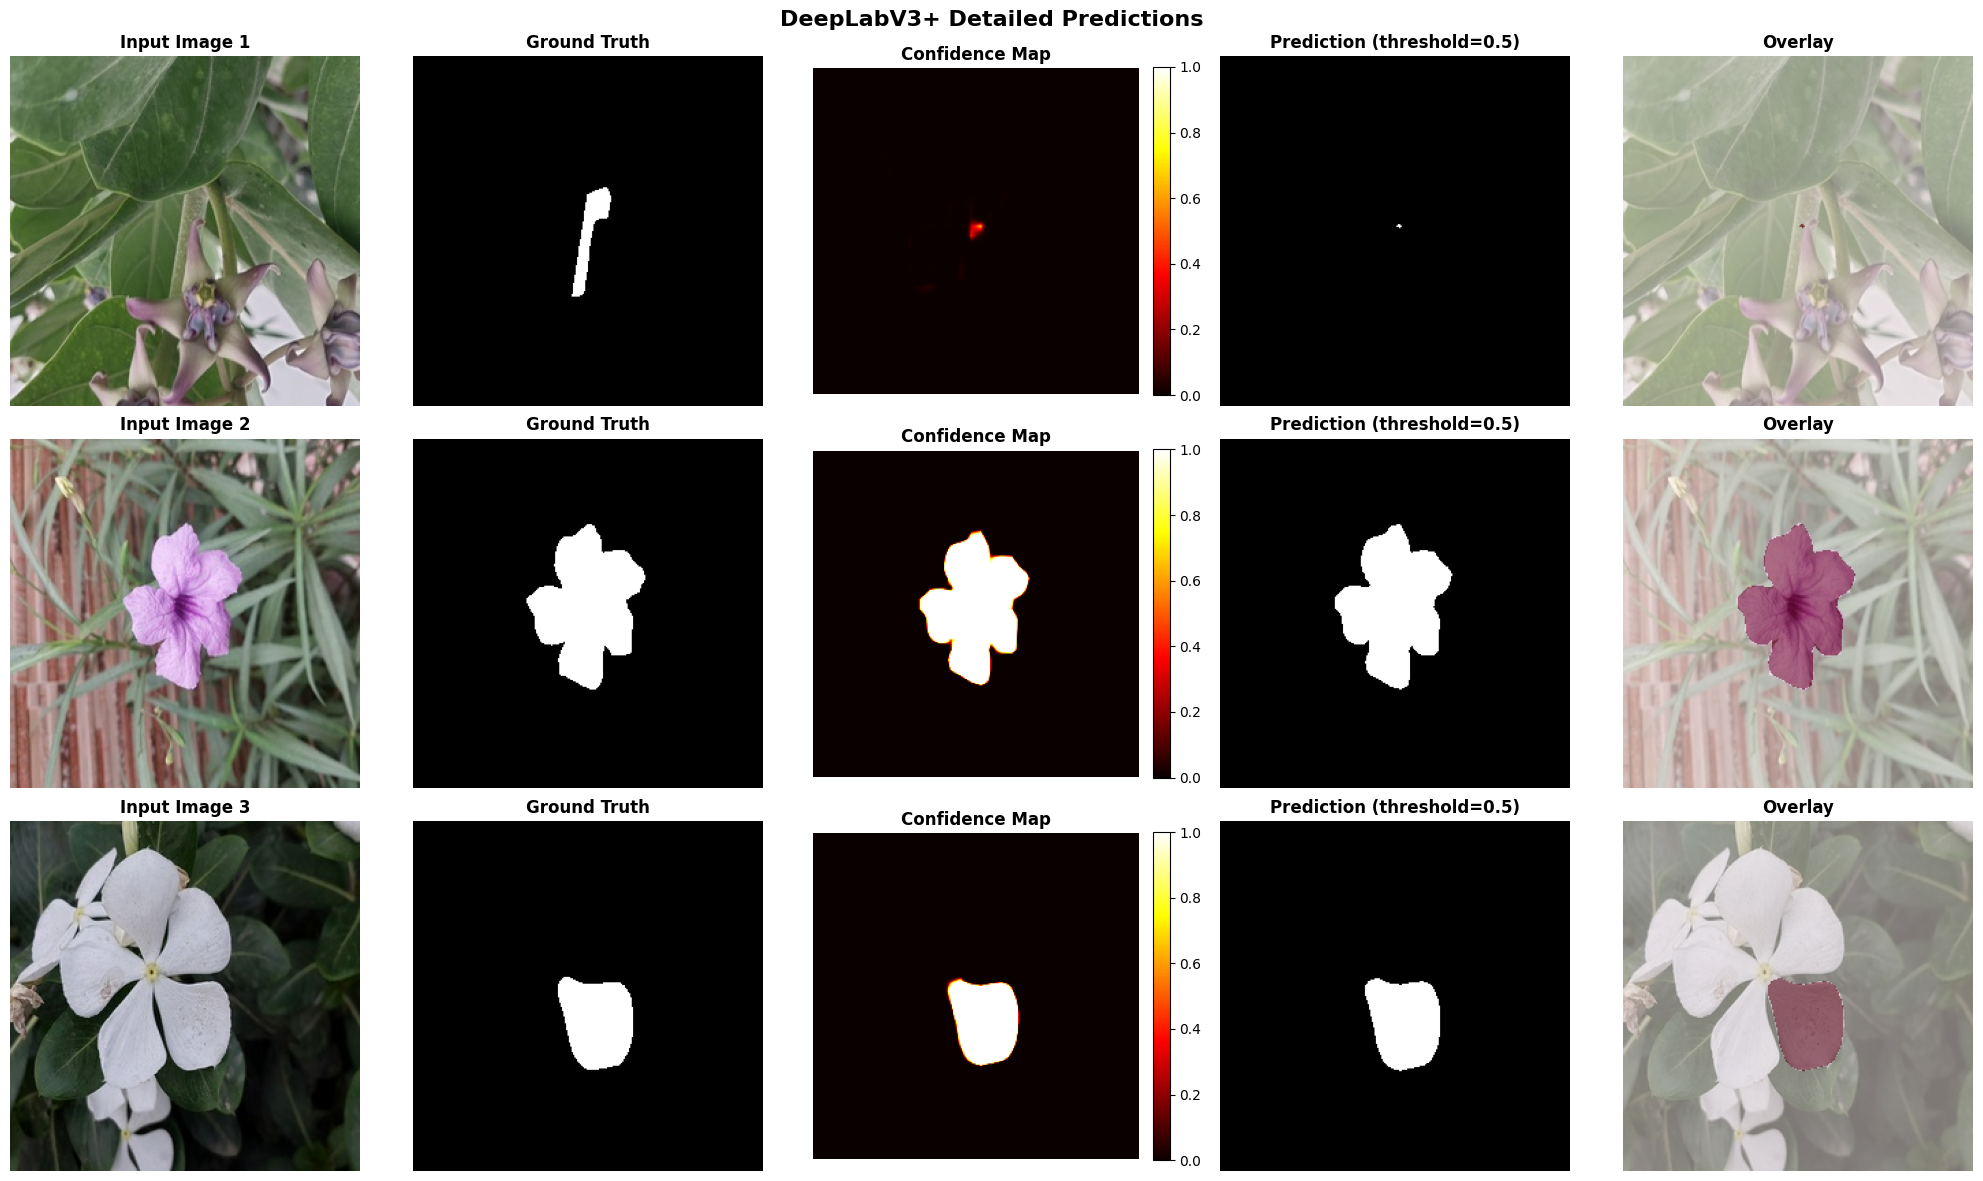


📊 PERFORMANCE METRICS:
Sample 1: Dice = 0.0140, IoU = 0.0071
Sample 2: Dice = 0.9890, IoU = 0.9783
Sample 3: Dice = 0.9909, IoU = 0.9820
Average: Dice = 0.6647, IoU = 0.6558


In [ ]:
# @title **Step 12: Enhanced DeepLabV3+ Visualization**
# @markdown Enhanced visualization with confidence maps

def visualize_deeplab_predictions_enhanced(model, dataloader, num_samples=3, threshold=0.5):
    """Enhanced visualization with confidence maps"""
    model.eval()

    # Get a batch of validation data
    images, masks = next(iter(dataloader))
    images = images.to(DEVICE)

    # Get predictions
    with torch.no_grad():
        outputs = model(images)
        if isinstance(outputs, dict):
            preds_logits = outputs['out']
            aux_logits = outputs.get('aux', None)
        else:
            preds_logits = outputs
            aux_logits = None

        preds_probs = torch.sigmoid(preds_logits)
        preds_binary = (preds_probs > threshold).float()

        if aux_logits is not None:
            aux_probs = torch.sigmoid(aux_logits)

    # Move to CPU for visualization
    images = images.cpu()
    masks = masks.cpu()
    preds_probs = preds_probs.cpu()
    preds_binary = preds_binary.cpu()

    # Plot results
    fig, axes = plt.subplots(num_samples, 5 if aux_logits is not None else 4,
                             figsize=(20 if aux_logits is not None else 16, 4*num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_samples):
        if i >= len(images):
            break

        col = 0

        # Original Image
        axes[i, col].imshow(images[i].permute(1, 2, 0))
        axes[i, col].set_title(f"Input Image {i+1}", fontweight='bold')
        axes[i, col].axis('off')
        col += 1

        # Ground Truth Mask
        axes[i, col].imshow(masks[i].squeeze(), cmap='gray')
        axes[i, col].set_title("Ground Truth", fontweight='bold')
        axes[i, col].axis('off')
        col += 1

        # Confidence Map
        prob_map = axes[i, col].imshow(preds_probs[i].squeeze(), cmap='hot', vmin=0, vmax=1)
        axes[i, col].set_title("Confidence Map", fontweight='bold')
        axes[i, col].axis('off')
        plt.colorbar(prob_map, ax=axes[i, col], fraction=0.046, pad=0.04)
        col += 1

        # Binary Prediction
        axes[i, col].imshow(preds_binary[i].squeeze(), cmap='gray')
        axes[i, col].set_title(f"Prediction (threshold={threshold})", fontweight='bold')
        axes[i, col].axis('off')
        col += 1

        # Overlay
        axes[i, col].imshow(images[i].permute(1, 2, 0))
        axes[i, col].imshow(preds_binary[i].squeeze(), cmap='Reds', alpha=0.5)
        axes[i, col].set_title("Overlay", fontweight='bold')
        axes[i, col].axis('off')
        col += 1

        # Auxiliary output if available
        if aux_logits is not None and col < axes.shape[1]:
            aux_prob = aux_probs[i].cpu().squeeze()
            axes[i, col].imshow(aux_prob, cmap='viridis')
            axes[i, col].set_title("Aux Output", fontweight='bold')
            axes[i, col].axis('off')

    plt.suptitle('DeepLabV3+ Detailed Predictions', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Calculate metrics
    print("\n📊 PERFORMANCE METRICS:")
    total_dice = 0
    total_iou = 0

    for i in range(min(num_samples, len(images))):
        dice, iou = calculate_metrics(preds_logits[i:i+1], masks[i:i+1].to(DEVICE))
        total_dice += dice
        total_iou += iou
        print(f"Sample {i+1}: Dice = {dice:.4f}, IoU = {iou:.4f}")

    if num_samples > 0:
        print(f"Average: Dice = {total_dice/num_samples:.4f}, IoU = {total_iou/num_samples:.4f}")

# Visualize with enhanced version
print("🎨 ENHANCED DEEPLABV3+ VISUALIZATION")
print("=" * 60)
visualize_deeplab_predictions_enhanced(model, val_loader, num_samples=3, threshold=0.5)